In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import multivariate_normal
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.distributions.multivariate_normal import MultivariateNormal
from vae.models import GaussVAE
from vae.trainers import GaussVAETrainer
from vae.neural_networks import EncoderGaussVAE, DecoderGaussVAE
from data.simple_geometry import (
    Superposition2D, Triforce, Stickman, DeathlyHallows, PlayStation
)
from data.transformations import ScaledTranslation, Rotation
from pathlib import Path
from tqdm import tqdm

# Data

In [2]:
size = 50000
sigma = 0.025

dataset = PlayStation()
dataset.sample(size, sigma)

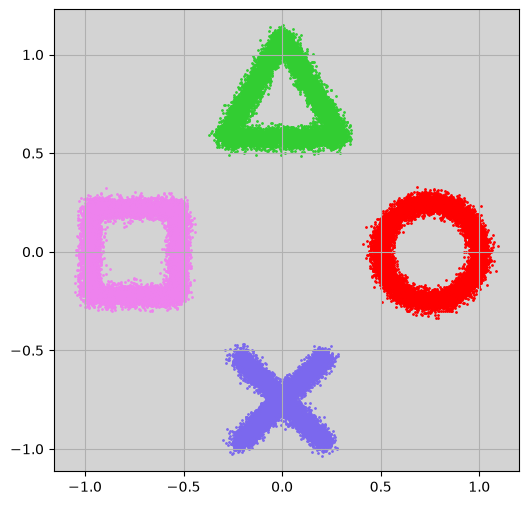

In [3]:
dataset.shape.plot(colour=["red", "violet", "limegreen", "mediumslateblue"])
# dataset.plot()
plt.axis("equal")
plt.show()

# Model

In [4]:
data_dim = 2
latent_dim = 2

encoder = EncoderGaussVAE(data_dim, latent_dim)
decoder = DecoderGaussVAE(data_dim, latent_dim)
encoder_decoder = nn.ModuleDict({
    "encoder" : encoder, 
    "decoder" : decoder
})

In [5]:
sigma = 0.025
model = GaussVAE(encoder, decoder, sigma)

# Training

In [6]:
batch_size = 8
lr = 1e-4

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
optimizer = Adam(encoder_decoder.parameters(), lr=lr)
trainer = GaussVAETrainer(model, dataloader, optimizer)

In [7]:
n_epochs = 10
n_latent = 64
log_dir = Path("/Users/aymanchaouki/Documents/Personal/projects/generative-models/runs/")
n_log = 1

trainer.train(n_epochs, n_latent, log_dir, n_log)

# Evaluation

In [8]:
n_samples = 10000
X_sampled = model.sample(n_samples)

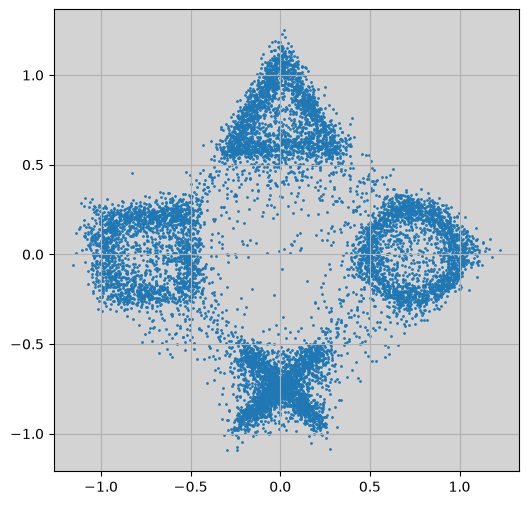

In [9]:
fig_size = (6, 6)
fig, ax = plt.subplots(1, 1, figsize=fig_size)
ax.scatter(X_sampled[:, 0], X_sampled[:, 1], s=1)
ax.grid()

ax.set_facecolor("lightgrey")
plt.axis("equal")
plt.show()

# Analysis of the latent structure

## Modes of the latent conditional $p_{\mathrm{encoder}}\left( Z | X\right)$

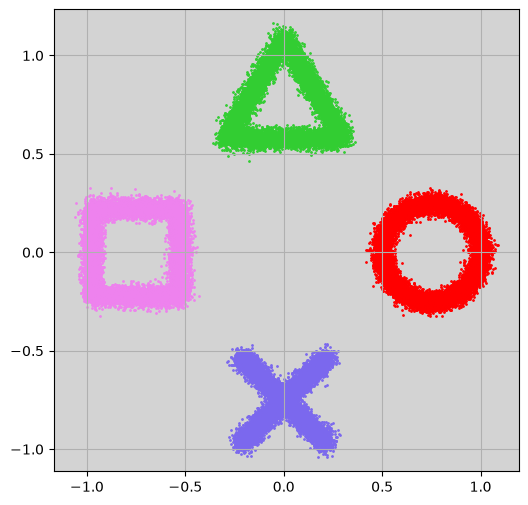

In [10]:
dataset.sample(size, sigma)
dataset.shape.plot(colour=["red", "violet", "limegreen", "mediumslateblue"])
# dataset.plot()
plt.axis("equal")
plt.show()

In [11]:
quotient, remainder = divmod(size, dataset.shape.n_shapes)
shape_names = ["circle", "square", "triangle", "cross"]
shape_colours = ["red", "violet", "limegreen", "mediumslateblue"]
shape_points = {}
for i, shape_name in enumerate(shape_names):
    shape_size = quotient if i < dataset.shape.n_shapes-1 else quotient + remainder
    shape_points[shape_name] = dataset.X[i*quotient : i*quotient + shape_size, :]

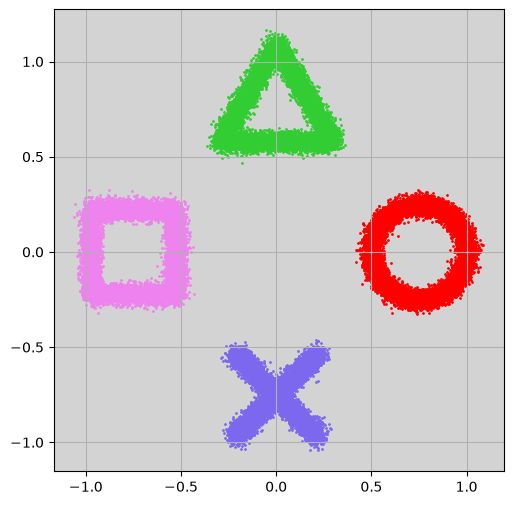

In [12]:
from data.utils import plot2D

ax1 = None
fig_size = (6, 6)
for i, shape_name in enumerate(shape_points):
    ax1 = plot2D(shape_points[shape_name], ax1, fig_size, shape_colours[i])

plt.show()

In [13]:
encoded_shapes = {}
for shape_name in shape_points:
    with torch.no_grad():
        encoded_shapes[shape_name] = model.encoder(torch.from_numpy(shape_points[shape_name]))[0].numpy()

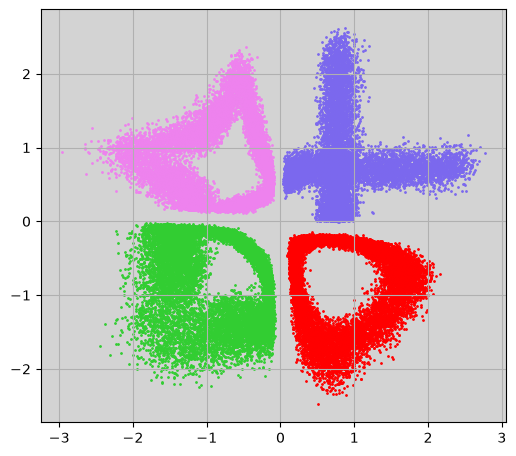

In [14]:
fig_size = (6, 6)
fig, ax2 = plt.subplots(1, 1, figsize=fig_size)
ax2.grid()
ax2.set_facecolor("lightgrey")
ax2.set_aspect("equal")
for i, shape_name in enumerate(encoded_shapes):
    ax2.scatter(encoded_shapes[shape_name][:, 0], encoded_shapes[shape_name][:, 1], s=1, c=shape_colours[i])

plt.show()

## Analysis of the encoder's conditionals $p_{\mathrm{encoder}}\left( Z | X \in \mathrm{shape}\right)$

In [65]:
def encoder_conditional(x: np.ndarray, y: np.ndarray, points: np.ndarray) -> np.ndarray:
    z = torch.from_numpy(np.hstack((x.reshape((-1, 1)), y.reshape((-1, 1)))))
    probs = np.zeros(z.shape[0])
    with torch.no_grad():
        gauss_params = model.encoder(torch.from_numpy(points))
        
    for i in tqdm(range(points.shape[0]), desc="log-probabilities"):
        e = MultivariateNormal(gauss_params[0][i], torch.diag(torch.exp(gauss_params[1][i])))
        probs += torch.exp(e.log_prob(z)).numpy()

    probs /= points.shape[0]
    return probs

In [91]:
x = np.linspace(-2.5, 2.5, 100)
y = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(x, y)

In [92]:
conditional_circle = encoder_conditional(X, Y, shape_points["circle"])
conditional_square = encoder_conditional(X, Y, shape_points["square"])
conditional_triangle = encoder_conditional(X, Y, shape_points["triangle"])
conditional_cross = encoder_conditional(X, Y, shape_points["cross"])

log-probabilities: 100%|██████████| 12500/12500 [00:10<00:00, 1138.14it/s]


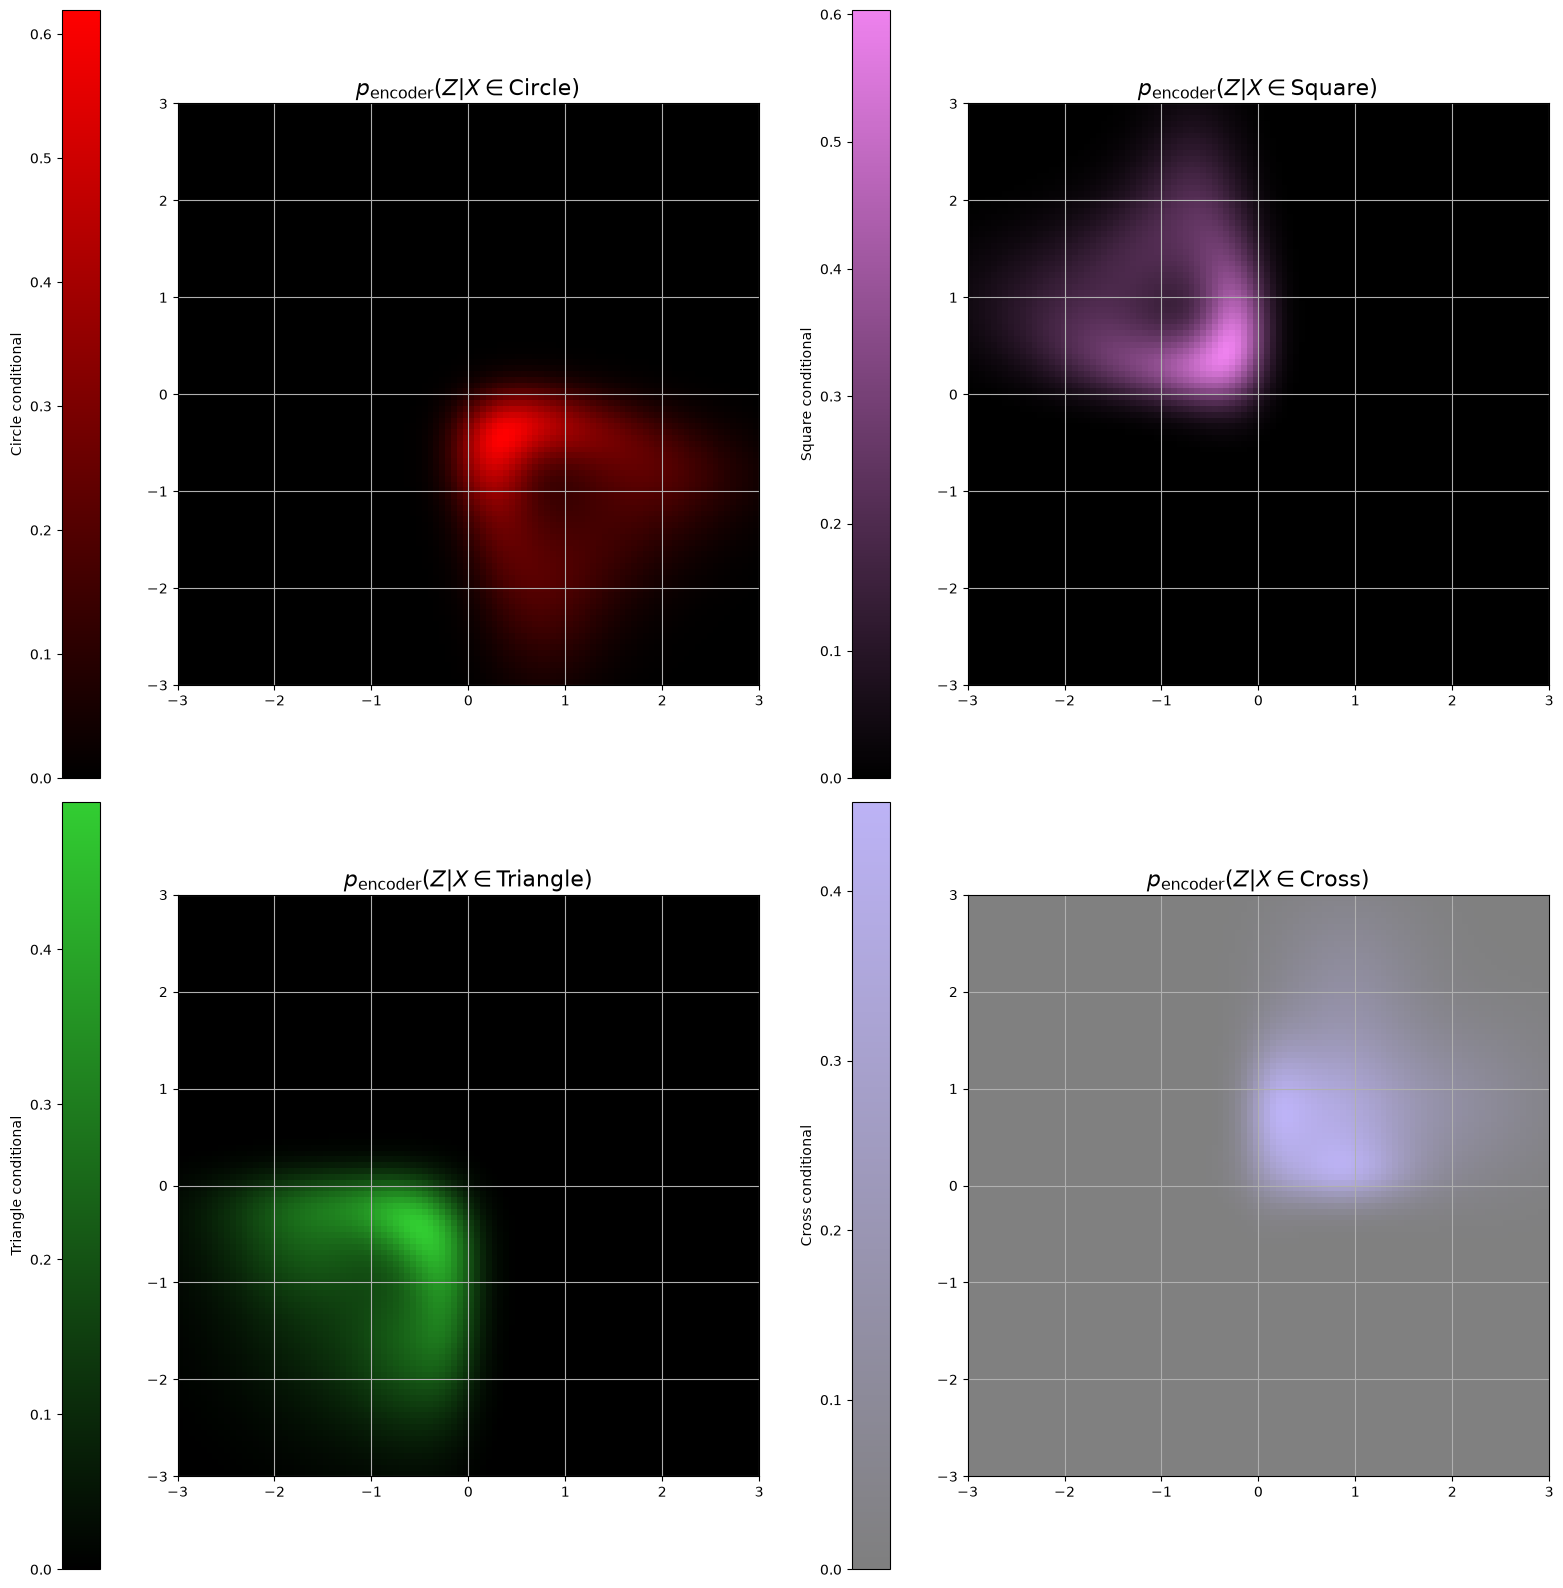

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

ax = axes[0, 0]
im_circle = ax.imshow(
    conditional_circle.reshape((100, 100)),
    extent=[-2.5, 2.5, -2.5, 2.5],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("red", ["black", "red"]),
    aspect='equal'
)
ax.set_title(r"$p_{\mathrm{encoder}}(Z | X \in \mathrm{Circle})$", fontsize="16")
ax.grid()

ax = axes[0, 1]
im_square = ax.imshow(
    conditional_square.reshape((100, 100)),
    extent=[-2.5, 2.5, -2.5, 2.5],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("violet", ["black", "violet"]),
    aspect='equal', 
)
ax.set_title(r"$p_{\mathrm{encoder}}(Z | X \in \mathrm{Square})$", fontsize="16")
ax.grid()

ax = axes[1, 0]
im_triangle = ax.imshow(
    conditional_triangle.reshape((100, 100)),
    extent=[-2.5, 2.5, -2.5, 2.5],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("limegreen", ["black", "limegreen"]),
    aspect='equal'
)
ax.set_title(r"$p_{\mathrm{encoder}}(Z | X \in \mathrm{Triangle})$", fontsize="16")
ax.grid()

ax = axes[1, 1]
im_cross = ax.imshow(
    conditional_cross.reshape((100, 100)),
    extent=[-2.5, 2.5, -2.5, 2.5],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("mediumslateblue", ["black", "mediumslateblue"]),
    aspect='equal', 
    alpha=0.5
)
ax.set_title(r"$p_{\mathrm{encoder}}(Z | X \in \mathrm{Cross})$", fontsize="16")
ax.grid()

cbar1 = fig.colorbar(im_circle, ax=axes[0, 0], location='left', pad=0.1)
cbar1.set_label('Circle conditional')

cbar2 = fig.colorbar(im_square, ax=axes[0, 1], location='left', pad=0.1)
cbar2.set_label('Square conditional')

cbar3 = fig.colorbar(im_triangle, ax=axes[1, 0], location='left', pad=0.1)
cbar3.set_label('Triangle conditional')

cbar4 = fig.colorbar(im_cross, ax=axes[1, 1], location='left', pad=0.1)
cbar4.set_label('Cross conditional')

plt.tight_layout()
plt.show()

## Analysis of the encoder's marginal $p_{\mathrm{encoder}}\left( Z\right)$

In [95]:
marginal = encoder_conditional(X, Y, dataset.X)

log-probabilities: 100%|██████████| 50000/50000 [00:38<00:00, 1291.34it/s]


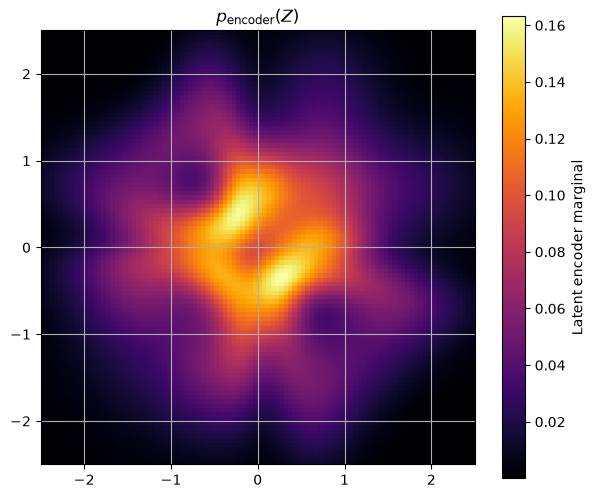

In [96]:
fig, ax = plt.subplots(figsize=(7, 6))

c = ax.imshow(
    marginal.reshape((100, 100)),
    extent=[-2.5, 2.5, -2.5, 2.5],
    origin='lower',
    cmap='inferno',
    aspect='equal'
)
ax.grid()
fig.colorbar(c, ax=ax, label="Latent encoder marginal")
ax.set_title(r"$p_{\mathrm{encoder}}(Z)$")

plt.show()

## Analysis of the decoder's conditionals $p_{\mathrm{decoder}}\left( Z | X \in \mathrm{shape}\right)$

In [81]:
def decoder_conditional(x: np.ndarray, y: np.ndarray, points: np.ndarray) -> np.ndarray:
    z = torch.from_numpy(np.hstack((x.reshape((-1, 1)), y.reshape((-1, 1))), dtype=np.float32))
    e_standard = MultivariateNormal(torch.zeros(2), torch.eye(2))
    prior = torch.exp(e_standard.log_prob(z))
    probs = torch.zeros(z.shape[0])
    with torch.no_grad():
        gauss_params = model.decoder(z)
        
    for i in tqdm(range(z.shape[0]), desc="log-probabilities"):
        e = MultivariateNormal(gauss_params[i], sigma**2*torch.eye(2))
        probs[i] = torch.exp(e.log_prob(torch.from_numpy(points))).mean()
        
    probs = prior*probs*dataset.X.shape[0]
    return probs.numpy()

In [87]:
x = np.linspace(-2.5, 2.5, 100)
y = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(x, y)

In [88]:
decoder_circle = decoder_conditional(X, Y, shape_points["circle"])
decoder_square = decoder_conditional(X, Y, shape_points["square"])
decoder_triangle = decoder_conditional(X, Y, shape_points["triangle"])
decoder_cross = decoder_conditional(X, Y, shape_points["cross"])

log-probabilities:   0%|          | 0/10000 [00:00<?, ?it/s]

log-probabilities: 100%|██████████| 10000/10000 [00:08<00:00, 1188.63it/s]


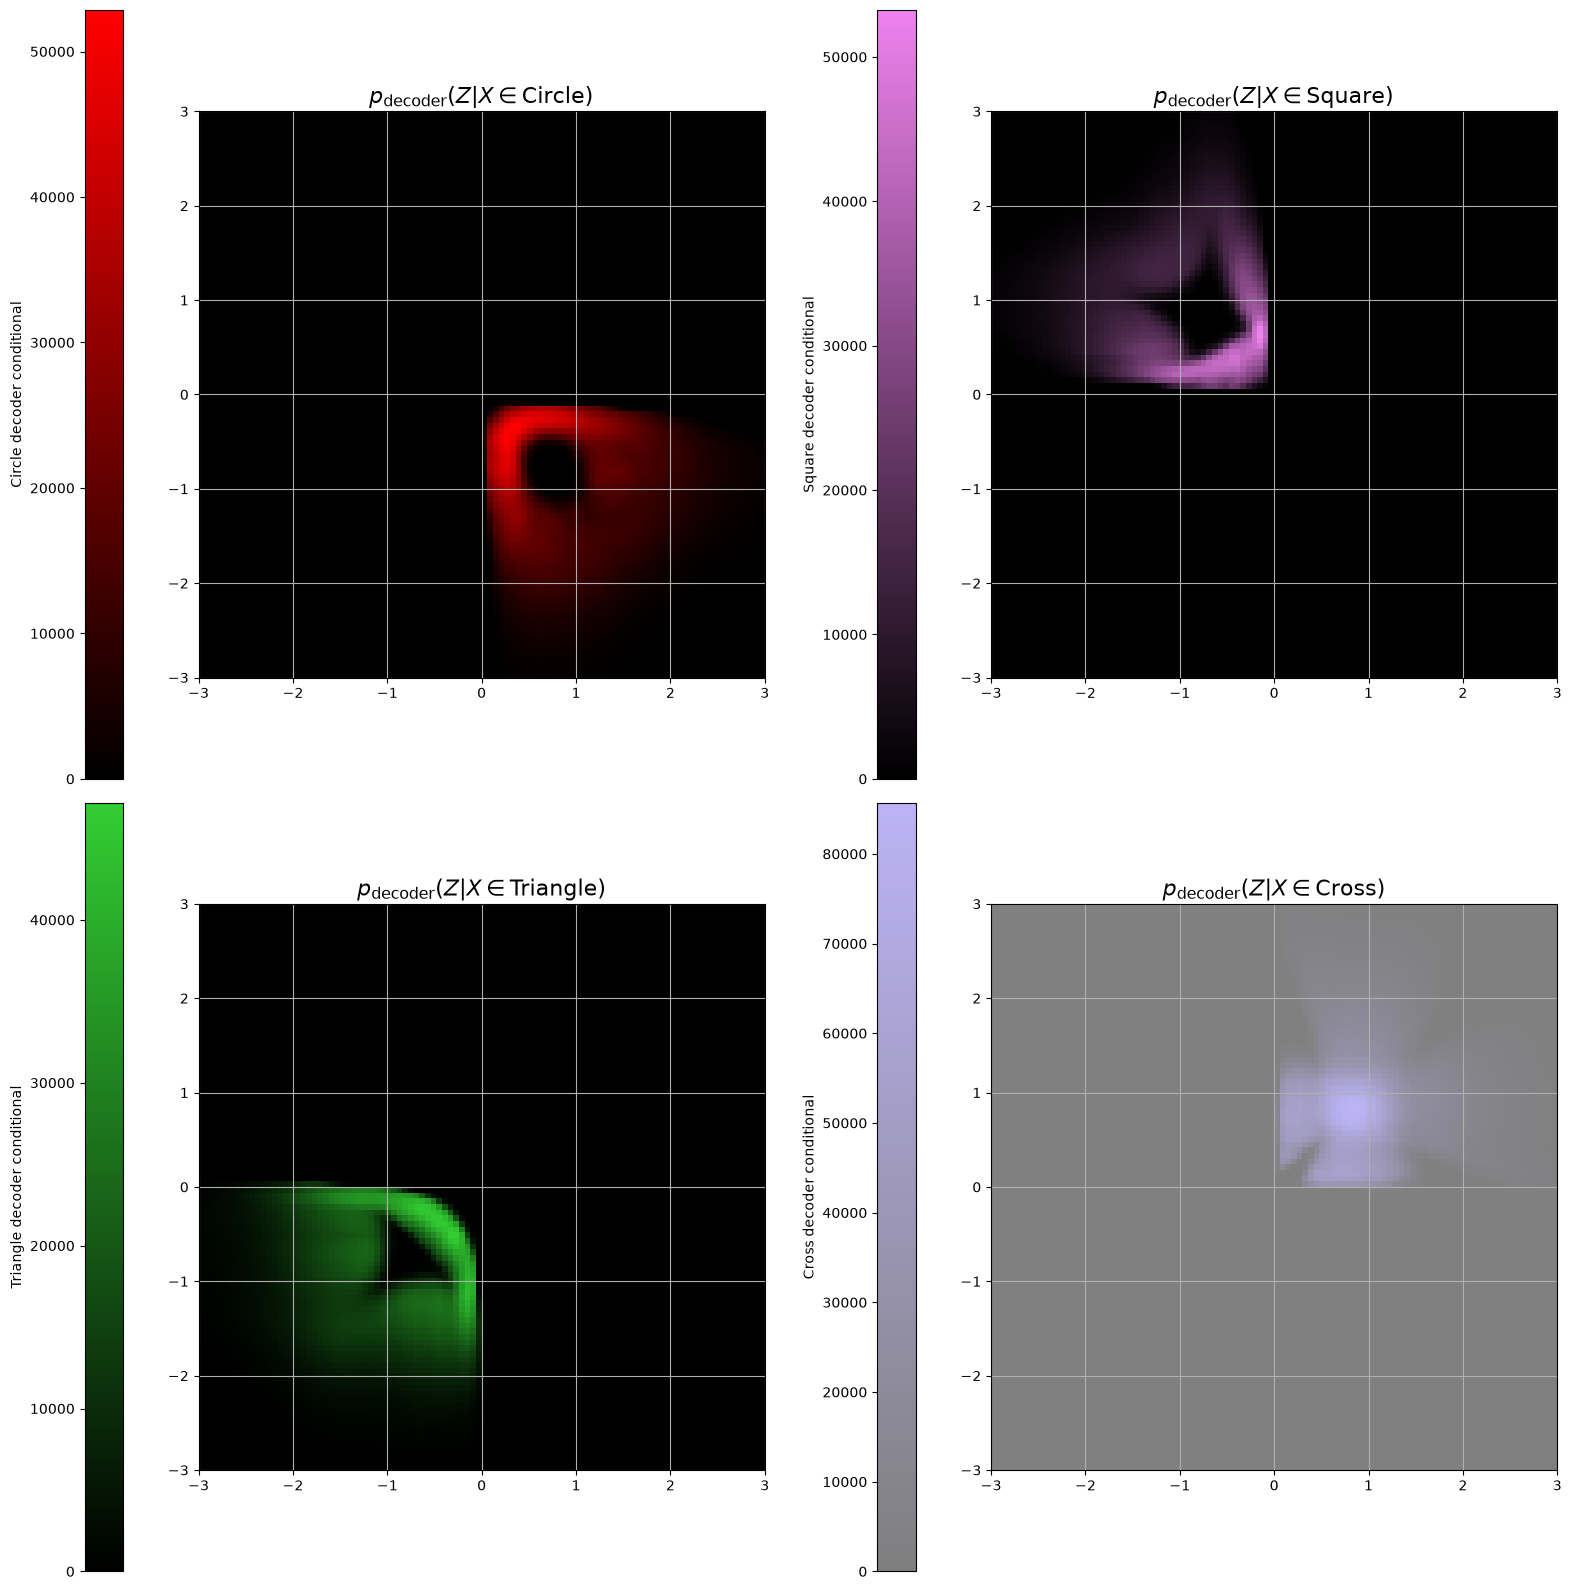

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

ax = axes[0, 0]
im_circle = ax.imshow(
    decoder_circle.reshape((100, 100)),
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("red", ["black", "red"]),
    aspect='equal'
)
ax.set_title(r"$p_{\mathrm{decoder}}(Z | X \in \mathrm{Circle})$", fontsize="16")
ax.grid()

ax = axes[0, 1]
im_square = ax.imshow(
    decoder_square.reshape((100, 100)),
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("violet", ["black", "violet"]),
    aspect='equal', 
)
ax.set_title(r"$p_{\mathrm{decoder}}(Z | X \in \mathrm{Square})$", fontsize="16")
ax.grid()

ax = axes[1, 0]
im_triangle = ax.imshow(
    decoder_triangle.reshape((100, 100)),
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("limegreen", ["black", "limegreen"]),
    aspect='equal'
)
ax.set_title(r"$p_{\mathrm{decoder}}(Z | X \in \mathrm{Triangle})$", fontsize="16")
ax.grid()

ax = axes[1, 1]
im_cross = ax.imshow(
    decoder_cross.reshape((100, 100)),
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap=LinearSegmentedColormap.from_list("mediumslateblue", ["black", "mediumslateblue"]),
    aspect='equal', 
    alpha=0.5
)
ax.set_title(r"$p_{\mathrm{decoder}}(Z | X \in \mathrm{Cross})$", fontsize="16")
ax.grid()

cbar1 = fig.colorbar(im_circle, ax=axes[0, 0], location='left', pad=0.1)
cbar1.set_label('Circle decoder conditional')

cbar2 = fig.colorbar(im_square, ax=axes[0, 1], location='left', pad=0.1)
cbar2.set_label('Square decoder conditional')

cbar3 = fig.colorbar(im_triangle, ax=axes[1, 0], location='left', pad=0.1)
cbar3.set_label('Triangle decoder conditional')

cbar4 = fig.colorbar(im_cross, ax=axes[1, 1], location='left', pad=0.1)
cbar4.set_label('Cross decoder conditional')

plt.tight_layout()
plt.show()